In [1]:
import numpy as np
import pandas as pd

In [2]:
def calc_mae(y:pd.Series, yhat) -> float:
    if type(yhat) == type(pd.DataFrame()):
        for col in yhat.columns:
            mae=(y-yhat[col]).abs().mean()
            print(f'MAE {col} = \t{mae:.4f}')
    else:
        return (y-yhat).abs().mean()

# Persist

In [3]:
day_cutoff = 5
hour_cutoff = [6,10]
freq = '1h'
dppd = int( {'1h':24,'15min':96}[freq] * (hour_cutoff[1]-hour_cutoff[0])/24 )
print('Data points per day:',dppd)

df_full = pd.read_csv(  'data/all_JPL_v5.csv',
                        index_col=0,
                        parse_dates=True,comment='#')\
                        .drop(columns=['Fake'])\
                        .resample('1h').mean()

df = df_full[df_full.index.weekday<day_cutoff]
df = df[df.index.hour.isin(range(hour_cutoff[0],hour_cutoff[1]))]

df['Persist1D'] = df['Load'].shift(dppd)
df['Persist5D'] = df['Load'].shift(dppd*5)
df['Persist7D'] = df['Load'].shift(dppd*7)

df = df[dppd*7:].copy()

df = (df-df.min())/(df.max()-df.min())

print('NaNs:',df.isna().sum().sum())

Data points per day: 4
NaNs: 0


In [4]:
calc_mae(df.Load,df)

MAE Load = 	0.0000
MAE Persist1Workday = 	0.0998
MAE Persist1D = 	0.1409
MAE Persist5D = 	0.1443
MAE Persist7D = 	0.1512


In [5]:
for col in df.columns:
    df[col+'Tform'] = np.log(df[col]+1e-1)
    
df = (df-df.min())/(df.max()-df.min())

In [6]:
df.corr()[['Load','LoadTform']]

,Load,LoadTform
Load,1.000000,0.978716
Persist1Workday,0.791144,0.766481
Persist1D,0.594504,0.550376
Persist5D,0.602584,0.553323
Persist7D,0.579882,0.528627
LoadTform,0.978716,1.000000
Persist1WorkdayTform,0.752042,0.748120
Persist1DTform,0.543243,0.503995
Persist5DTform,0.556190,0.511870
Persist7DTform,0.532864,0.484646


MAE Load = 	0.0000
MAE Persist1D = 	0.1726
MAE Persist7D = 	0.1715
MAE Persist1Workday = 	0.1319


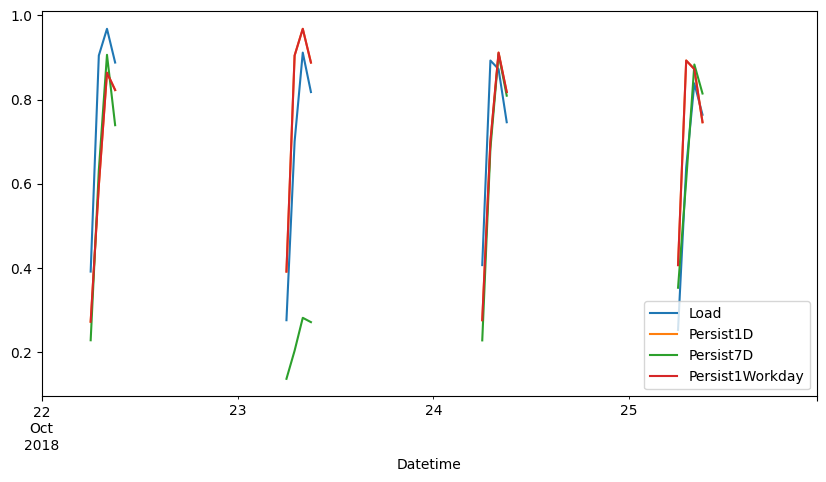

In [7]:
df_full['Load'] = np.nan
df_full['Persist1D'] = np.nan
df_full['Persist7D'] = np.nan
df_full['Persist1Workday'] = np.nan

df_full.loc[df.index,'Load'] = df.Load.values
df_full.loc[df.index,'Persist1D'] = df.Persist1D.values
df_full.loc[df.index,'Persist7D'] = df.Persist7D.values
df_full.loc[df.index,'Persist1Workday'] = df.Persist1Workday.values

calc_mae(df_full.loc['2018-10-15':'2018-10-29',['Load','Persist1D','Persist7D','Persist1Workday']].Load,
         df_full.loc['2018-10-15':'2018-10-29',['Load','Persist1D','Persist7D','Persist1Workday']])

df_full.loc['2018-10-22':'2018-10-25',['Load','Persist1D','Persist7D','Persist1Workday']].plot(figsize=(10,5));

<Axes: xlabel='Load', ylabel='Persist1Workday'>

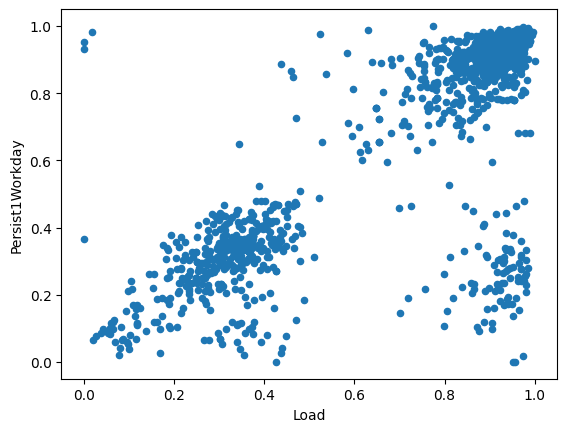

In [8]:
df.plot(x='Load',y='Persist1Workday',kind='scatter')

# Peaks

/tmp/ipykernel_29386/1624840077.py:7: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max['hour' ].append(df_day[name].idxmax().hour)
/tmp/ipykernel_29386/1624840077.py:7: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max['hour' ].append(df_day[name].idxmax().hour)
/tmp/ipykernel_29386/1624840077.py:7: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max['hour' ].append(df_day[name].idxmax().hour)
/tmp/ipykernel_29386/1624840077.py:7: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max['hour' ].append(df_day[name].idxmax().hour)
/tmp/ipykernel_29386/1624840

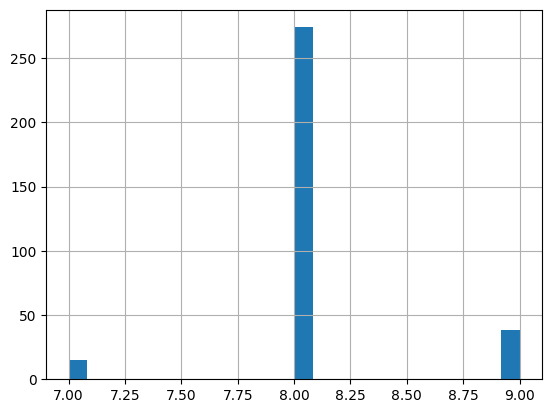

In [9]:
def calc_peaks(df:pd.DataFrame,name='Load') -> pd.DataFrame:
    max = {'hour':[],'value':[]}
    for year in df.index.year.unique():
        for month in df.loc[f'{year}'].index.month.unique():
            for day in df.loc[f'{year}-{month}'].index.day.unique():
                df_day = df.loc[f'{year}-{month}-{day}']
                max['hour' ].append(df_day[name].idxmax().hour)
                max['value'].append(df_day[name].max())
    return pd.DataFrame(max)

df_peaks = calc_peaks(df_full)
df_peaks.hour.hist(bins=24);